In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import umap
from sklearn.preprocessing import StandardScaler
import umap.plot
import numpy
import matplotlib.cm as cmap
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
import sys
sys.path.insert(0, r'C:\Users\nVoke\PycharmProjects\pythonProject1\tools')


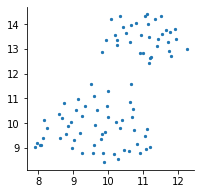

In [ ]:
root_path = r'F:\jcy\humen_brain\revision20251127\Q4'
seed_num = 6
np.random.seed(seed_num)
summary_features=pd.read_excel(root_path+'\\inhibitory.xlsx',index_col=0)

prefix = 'inhibitory'
summary_features.fillna(method = 'pad', axis =0, inplace=True, limit=None)
sum_fea_scaler=StandardScaler().fit_transform(summary_features)
sum_fea_scaler=pd.DataFrame(sum_fea_scaler,index=summary_features.index,columns=summary_features.columns)
umap_vals = umap.UMAP(n_neighbors=15,n_components=2, random_state=seed_num).fit_transform(sum_fea_scaler)

plt.figure(figsize=(3,3),facecolor='white')
plt.scatter(*umap_vals.T,s=5,edgecolors=None)
sns.despine()


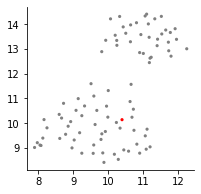

In [ ]:
sum_fea_scaler = StandardScaler().fit_transform(summary_features)
sum_fea_scaler = pd.DataFrame(sum_fea_scaler, index=summary_features.index, columns=summary_features.columns)

umap_vals = umap.UMAP(n_neighbors=15, n_components=2, random_state=seed_num).fit_transform(sum_fea_scaler)

colors = ['red' if idx == 'temporal_lobe_1118_cell5' else 'gray' for idx in summary_features.index]

plt.figure(figsize=(3,3), facecolor='white')
plt.scatter(umap_vals[:,0], umap_vals[:,1], s=10, c=colors, edgecolors='none',linewidths=0)
sns.despine()
plt.savefig(root_path+f'\\clusetring by PV_Homer.pdf')
plt.show()

C:\ProgramData\Anaconda3\envs\pythonProject1\lib\site-packages\sklearn\cluster\_kmeans.py:1332: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


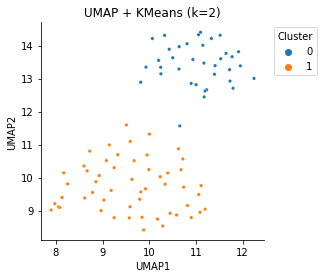

✅ 聚类完成，细胞名单已导出：
F:\jcy\humen_brain\revision20251127\Q4\UMAP_KMeans_2clusters_cells.xlsx

各类细胞数量：
0    36
1    53
Name: cluster, dtype: int64


In [ ]:
np.random.seed(seed_num)

N_CLUSTERS = 2

root_path = r'F:\jcy\humen_brain\revision20251127\Q4'
summary_features = pd.read_excel(root_path + '\\inhibitory.xlsx')
prefix = 'inhibitory'

cell_names = summary_features['cell_name']

features = summary_features.drop(columns=['cell_name'])
features.fillna(method='pad', axis=0, inplace=True)

X_scaled = StandardScaler().fit_transform(features)

umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    random_state=seed_num
)
umap_vals = umap_model.fit_transform(X_scaled)

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=seed_num,
    n_init=10
)
labels = kmeans.fit_predict(umap_vals)

result_df = pd.DataFrame({
    'cell_name': cell_names,
    'UMAP1': umap_vals[:, 0],
    'UMAP2': umap_vals[:, 1],
    'cluster': labels
})

plt.figure(figsize=(4,4))
sns.scatterplot(
    data=result_df,
    x='UMAP1',
    y='UMAP2',
    hue='cluster',
    palette='tab10',
    s=12
)
plt.title(f'UMAP + KMeans (k={N_CLUSTERS})')
plt.legend(title='Cluster', bbox_to_anchor=(1.02,1))
sns.despine()
plt.show()

cluster_dict = {}
for cid in sorted(result_df['cluster'].unique()):
    cluster_dict[f'cluster_{cid}'] = result_df[result_df['cluster']==cid]['cell_name'].reset_index(drop=True)

out_excel = root_path + f'\\UMAP_KMeans_{N_CLUSTERS}clusters_cells.xlsx'
pd.DataFrame(cluster_dict).to_excel(out_excel, index=False)

print(out_excel)

print("\n各类细胞数量：")
print(result_df['cluster'].value_counts().sort_index())

In [ ]:
###screening occipital, frontal, temporal PV neuron
path=r'F:\jcy\humen_brain\electrophysiology\all_nerons'
file_inhibitory=pd.read_excel(path+'\\properties_firing.xlsx',sheet_name='inhibitory')
pv_cell=file_inhibitory[(file_inhibitory['cell_type_identify']=='Pvalb')]  ###& (file_inhibitory['brain_region']=='occipital_lobe'
pv_cell=list(pv_cell['cell_name'])

occi_pv=file_inhibitory[(file_inhibitory['cell_type_identify']=='Pvalb') & (file_inhibitory['brain_region']=='occipital_lobe')]
occi_pv=list(occi_pv['cell_name'])
fron_pv=file_inhibitory[(file_inhibitory['cell_type_identify']=='Pvalb') & (file_inhibitory['brain_region']=='frontal_lobe')]
fron_pv=list(fron_pv['cell_name'])
temp_pv=file_inhibitory[(file_inhibitory['cell_type_identify']=='Pvalb') & (file_inhibitory['brain_region']=='temporal_lobe')]
temp_pv=list(temp_pv['cell_name'])
print(np.array(occi_pv).reshape(-1,1))

[['occipital_lobe_1121_cell4']
 ['occipital_lobe_1121_cell6']
 ['occipital_lobe_1121_cell7']
 ['occipital_lobe_1121_cell14']
 ['occipital_lobe_1202_cell20']
 ['occipital_lobe_1202_cell23']
 ['occipital_lobe_1202_cell27']
 ['occipital_lobe_1206_cell7']
 ['occipital_lobe_1206_cell14']]


In [ ]:
pv_cluster=[i[0] for i in enumerate(sum_fea_scaler.index) if i[1] in pv_cell]

occip_pv_cluster=[i[0] for i in enumerate(sum_fea_scaler.index) if i[1] in occi_pv]

fron_pv_cluster=[i[0] for i in enumerate(sum_fea_scaler.index) if i[1] in fron_pv]
temp_pv_cluster=[i[0] for i in enumerate(sum_fea_scaler.index) if i[1] in temp_pv]
print(f'location of pv neurons:{occip_pv_cluster}')

[i for i in occi_pv if i not in list(sum_fea_scaler.index)]

location of pv neurons:[34, 37, 38, 39, 44, 47, 52, 56]


['occipital_lobe_1202_cell27']

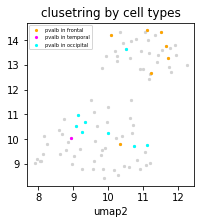

In [ ]:
plt.figure(figsize=(3,3))
plt.scatter(*umap_vals.T,s=5,c='lightgray',edgecolors=None)

plt.scatter(*umap_vals[fron_pv_cluster,:].T,s=10,c='orange',edgecolors=None,label='pvalb in frontal',linewidths=0)
plt.scatter(*umap_vals[temp_pv_cluster,:].T,s=10,c='magenta',edgecolors=None,label='pvalb in temporal',linewidths=0)
plt.scatter(*umap_vals[occip_pv_cluster,:].T,s=10,c='cyan',edgecolors=None,label='pvalb in occipital',linewidths=0)
###non-occipital pv within different region
# plt.scatter(*umap_vals[pv_cluster,:].T,s=5,c='r',edgecolors=None,label='pvalb')
plt.legend(fontsize=5)

# for i in enumerate(list(sum_fea_scaler.index)):
#     plt.annotate(i[1][-11:],umap_vals[i[0],:],textcoords='offset points')

plt.title('clusetring by cell types');plt.xlabel('umap1');plt.xlabel('umap2')
plt.savefig(root_path+f'\\clusetring by cell types_{prefix}.pdf')

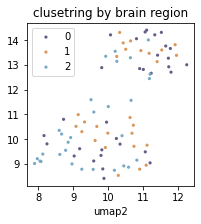

In [ ]:

sum_fea_scaler['tagets']=[i[:8] for i in sum_fea_scaler.index]
tagets=sum_fea_scaler['tagets']
encoder = LabelEncoder()
tagets = encoder.fit_transform(tagets)
encoder.classes_, np.unique(tagets, return_counts=True)
plt.figure(figsize=(3,3))
for color, i in zip(['#655c85','#d99759','#76a9c6'], [0, 1, 2]):
    plt.scatter(umap_vals[tagets==i, 0], umap_vals[tagets==i, 1],s=10, c=color, label=i,edgecolors='none',linewidths=0)
    plt.legend()
plt.title('clusetring by brain region');plt.xlabel('umap1');plt.xlabel('umap2')
plt.savefig(root_path+f'\\clusetring by brain region_{prefix}.pdf')

Index(['threshold_v', 'latency', 'peak_v', 'trough_v', 'peak_amp',
       'upstroke_downstroke_ratio', 'adaptation', 'isi_cv', 'avg_rate', 'tau',
       'sag', 'Rin', 'Cm', 'half_width', 'DepoR', 'RepoR', 'AHPAmp',
       'AHP_latency', 'RMP', 'IS1', 'IS2'],
      dtype='object')


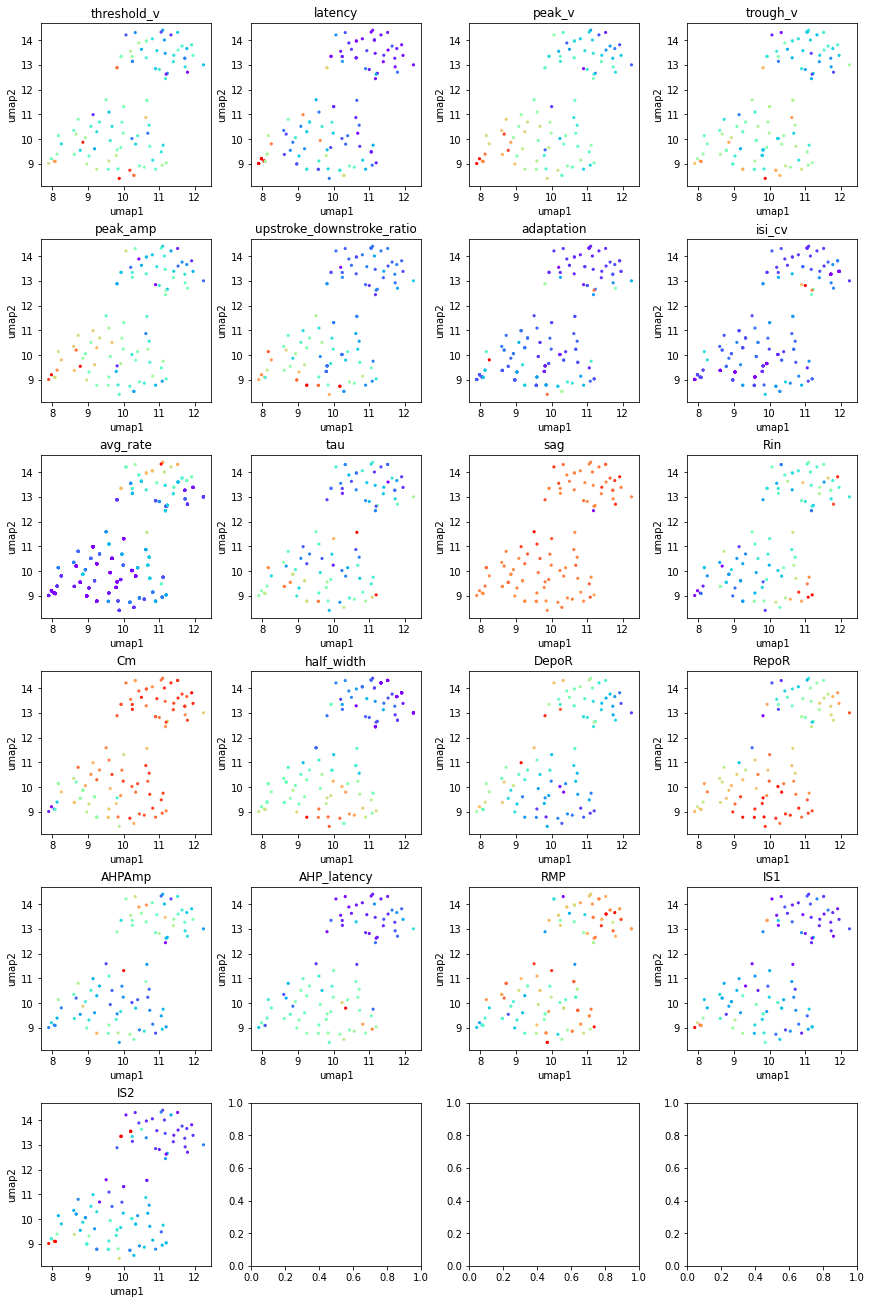

In [ ]:

parameters=sum_fea_scaler.columns[:-1]
print(parameters)
plt.subplots(nrows=6, ncols=4, figsize=(12,18),constrained_layout=True)
for i in enumerate(parameters):
    r =sum_fea_scaler[i[1]].values
    c = cmap.rainbow(numpy.int_((r-r.min())/r.ptp()*255))
    plt.subplot(6,4,i[0]+1)
    for color, cell in zip(c, r):
        plt.scatter(umap_vals[r==cell, 0], umap_vals[r==cell, 1],s=10, c=np.array(color).reshape(1,-1),edgecolors='none',linewidths=0)
    plt.title(i[1]);plt.xlabel('umap1');plt.ylabel('umap2')
plt.savefig(root_path+f'\\clusetring by parameters_{prefix}.pdf')
